# Task 2 — Predicting Frustration from Heart-Rate Features

**Goal:** a model that generalises to **new people** (subject-independent).

**CV schemes** (grounded in the course Day-4 slides + Raschka):
- **Primary — Leave-One-Subject-Out (LOSO)** = `GroupKFold(K=14)` on `Individual`.
  Slide 8's *leave-one-group-out*. The slide-9 caution against leave-one-**out** (K=N)
  concerns leaving out single correlated **rows**; leaving out a whole **subject**
  gives a genuinely independent test fold — exactly the "new person" estimand.
- **Support — `GroupKFold(K=5)`** on `Individual`: the slide-9 K=5/10 compromise
  (lower-variance estimate, same conclusion).
- **Stress — Leave-One-Cohort-Out** = `GroupKFold(K=2)` on `Cohort`: the harder
  *generalise-to-a-new-population* test.

**Target:** binary — `Frustrated >= 2` → 1 (frustrated), else 0. Chosen for balance
(74 vs 94, ~56% positive). `Frustrated` is a self-rated **0–10** scale (observed 0–8).

**Models:** majority baseline (`DummyClassifier`) vs **Logistic Regression** (linear)
vs **Random Forest** (non-linear). Scaling is fit **inside** each training fold.

**Tests:** McNemar (Edwards) + Wilcoxon signed-rank on the **same** LOSO folds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)
from scipy.stats import chi2, wilcoxon, shapiro

%matplotlib inline
SEED = 0
np.random.seed(SEED)

## 1. Load data and profile

In [2]:
df = pd.read_csv("HR_data.csv", index_col=0)
FEATURES = ["HR_Mean", "HR_Median", "HR_std", "HR_Min", "HR_Max", "HR_AUC"]
X = df[FEATURES].values
y = (df["Frustrated"] >= 2).astype(int).values     # 0=not-frustrated, 1=frustrated
subj = df["Individual"].values
cohort = df["Cohort"].values
N_SUBJECTS = len(np.unique(subj))
MAJ = max(np.bincount(y)) / len(y)

print(f"Dataset: {X.shape[0]} rows, {X.shape[1]} features, "
      f"{N_SUBJECTS} subjects, {len(np.unique(cohort))} cohorts")
print(f"Target (>=2): not-frustrated={int((y==0).sum())}, "
      f"frustrated={int((y==1).sum())} ({100*y.mean():.1f}% positive)")
print(f"Majority-class baseline = {MAJ:.3f}")
single = [int(s) for s in np.unique(subj) if len(np.unique(y[subj==s]))==1]
print(f"Single-class subjects under this cut: {single if single else 'none'}  "
      f"(their per-fold balanced-acc is degenerate)")
df.head()

Dataset: 168 rows, 6 features, 14 subjects, 2 cohorts
Target (>=2): not-frustrated=74, frustrated=94 (56.0% positive)
Majority-class baseline = 0.560
Single-class subjects under this cut: [7]  (their per-fold balanced-acc is degenerate)


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


## 2. Models

A fresh clone of each model is built per fold. The linear model is wrapped in a
`Pipeline` with `StandardScaler`, so scaling is fit **only on the training fold**
(slide 9 pt 2/6).

In [3]:
def make_models():
    return {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LR": Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
        "RF": RandomForestClassifier(n_estimators=200, max_features="sqrt",
                                     random_state=SEED, n_jobs=-1),
    }

MODEL_NAMES = ["Dummy", "LR", "RF"]

## 3. Grouped cross-validation helper

All models are fit/predicted within the **same** split iteration, so pooled
prediction arrays stay aligned sample-for-sample (needed for McNemar). The helper
takes the grouping array, so the same code serves subject- and cohort-grouping.

In [4]:
def run_grouped_cv(n_splits, group_array):
    gkf = GroupKFold(n_splits=n_splits)
    res = {n: {"y_true": [], "y_pred": [], "fold_acc": [], "fold_bacc": []}
           for n in MODEL_NAMES}
    for tr, te in gkf.split(X, y, group_array):
        models = make_models()
        for n in MODEL_NAMES:
            m = models[n].fit(X[tr], y[tr])
            pred = m.predict(X[te])
            res[n]["y_true"].extend(y[te]); res[n]["y_pred"].extend(pred)
            res[n]["fold_acc"].append(accuracy_score(y[te], pred))
            res[n]["fold_bacc"].append(balanced_accuracy_score(y[te], pred))
    for n in MODEL_NAMES:
        for k in res[n]:
            res[n][k] = np.array(res[n][k])
    return res


def mcnemar(res):
    lr_c = res["LR"]["y_pred"] == res["LR"]["y_true"]
    rf_c = res["RF"]["y_pred"] == res["RF"]["y_true"]
    b = int(np.sum(~lr_c & rf_c)); c = int(np.sum(lr_c & ~rf_c))
    stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) else 0.0
    p = float(1 - chi2.cdf(stat, df=1)) if (b + c) else 1.0
    return b, c, stat, p

## 4. Run the three schemes

In [5]:
loso = run_grouped_cv(N_SUBJECTS, subj)                 # PRIMARY
gk5  = run_grouped_cv(5, subj)                          # support
loco = run_grouped_cv(len(np.unique(cohort)), cohort)   # stress (leave-one-cohort-out)
schemes = [("LOSO (K=14) [PRIMARY]", loso),
           ("GroupKFold-5 [support]", gk5),
           ("Leave-One-Cohort-Out [stress]", loco)]

rows = []
for sname, res in schemes:
    for n in MODEL_NAMES:
        a, ba = res[n]["fold_acc"], res[n]["fold_bacc"]
        rows.append([sname, n, f"{a.mean():.3f} +/- {a.std():.3f}",
                     f"{ba.mean():.3f} +/- {ba.std():.3f}"])
pd.DataFrame(rows, columns=["scheme", "model", "accuracy", "balanced_acc"])

C:\Users\gusta\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\gusta\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\gusta\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,scheme,model,accuracy,balanced_acc
0,LOSO (K=14) [PRIMARY],Dummy,0.560 +/- 0.262,0.536 +/- 0.129
1,LOSO (K=14) [PRIMARY],LR,0.500 +/- 0.170,0.520 +/- 0.151
2,LOSO (K=14) [PRIMARY],RF,0.571 +/- 0.175,0.563 +/- 0.145
3,GroupKFold-5 [support],Dummy,0.553 +/- 0.067,0.500 +/- 0.000
4,GroupKFold-5 [support],LR,0.611 +/- 0.107,0.604 +/- 0.113
5,GroupKFold-5 [support],RF,0.581 +/- 0.075,0.571 +/- 0.092
6,Leave-One-Cohort-Out [stress],Dummy,0.302 +/- 0.031,0.500 +/- 0.000
7,Leave-One-Cohort-Out [stress],LR,0.328 +/- 0.005,0.518 +/- 0.018
8,Leave-One-Cohort-Out [stress],RF,0.420 +/- 0.024,0.528 +/- 0.003


## 5. Pooled report — primary scheme (LOSO)

In [6]:
for n in ["LR", "RF"]:
    print(f"[{n}]")
    print(classification_report(loso[n]["y_true"], loso[n]["y_pred"],
                                target_names=["Not-frustrated", "Frustrated"],
                                zero_division=0))

[LR]
                precision    recall  f1-score   support

Not-frustrated       0.41      0.30      0.34        74
    Frustrated       0.54      0.66      0.60        94

      accuracy                           0.50       168
     macro avg       0.48      0.48      0.47       168
  weighted avg       0.48      0.50      0.48       168

[RF]
                precision    recall  f1-score   support

Not-frustrated       0.52      0.38      0.44        74
    Frustrated       0.60      0.72      0.65        94

      accuracy                           0.57       168
     macro avg       0.56      0.55      0.55       168
  weighted avg       0.56      0.57      0.56       168



## 7. Model comparison on the same LOSO folds

In [7]:
b, c, mstat, mp = mcnemar(loso)
try:
    w_stat, w_p = wilcoxon(loso["LR"]["fold_acc"], loso["RF"]["fold_acc"])
except ValueError:
    w_stat, w_p = float("nan"), 1.0
dif = loso["RF"]["fold_acc"] - loso["LR"]["fold_acc"]

print("LR vs RF on LOSO folds:")
print(f"  McNemar (Edwards):     b={b} c={c}  chi2={mstat:.3f}  p={mp:.3f}")
print(f"  Wilcoxon signed-rank:  W={w_stat:.1f}  p={w_p:.3f}")
print(f"  Effect size dAcc = {loso['RF']['fold_acc'].mean()-loso['LR']['fold_acc'].mean():+.3f}"
      f"  (fold sd ~ {np.std(np.r_[loso['LR']['fold_acc'], loso['RF']['fold_acc']]):.3f})")
print(f"  fold-acc diffs: {len(set(np.round(dif,4)))} distinct values (discrete, 12 rows/fold); "
      f"Shapiro p={shapiro(dif).pvalue:.3f}  -> small discrete sample, Wilcoxon preferred")

LR vs RF on LOSO folds:
  McNemar (Edwards):     b=30 c=18  chi2=2.521  p=0.112
  Wilcoxon signed-rank:  W=19.5  p=0.229
  Effect size dAcc = +0.071  (fold sd ~ 0.176)
  fold-acc diffs: 7 distinct values (discrete, 12 rows/fold); Shapiro p=0.287  -> small discrete sample, Wilcoxon preferred


## 8. Figures

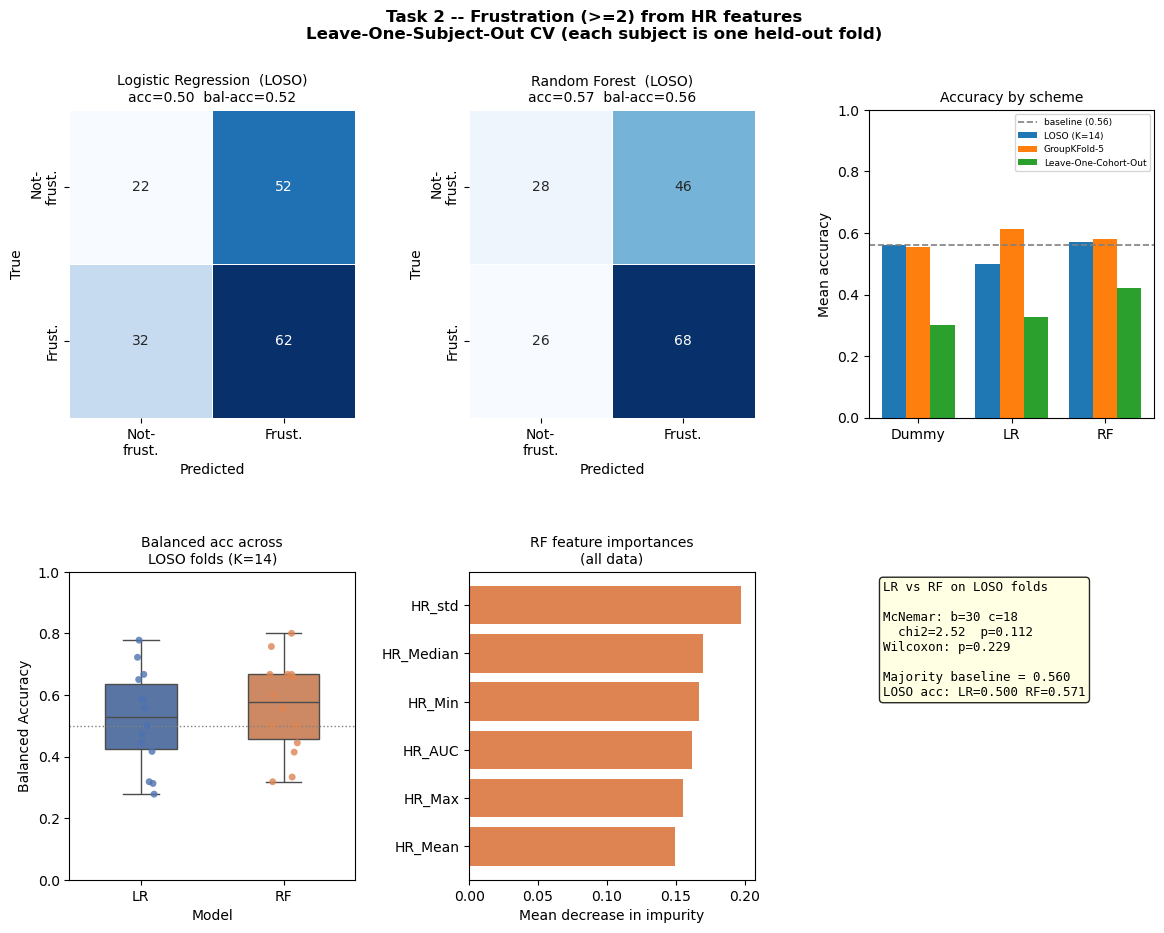

In [8]:
maj = MAJ
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)
CLASS = ["Not-\nfrust.", "Frust."]

for col, (n, label) in enumerate(zip(["LR", "RF"],
                                     ["Logistic Regression", "Random Forest"])):
    ax = fig.add_subplot(gs[0, col])
    cm = confusion_matrix(loso[n]["y_true"], loso[n]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS,
                yticklabels=CLASS, ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f"{label}  (LOSO)\nacc={loso[n]['fold_acc'].mean():.2f}  "
                 f"bal-acc={loso[n]['fold_bacc'].mean():.2f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

ax3 = fig.add_subplot(gs[0, 2])
xpos = np.arange(len(MODEL_NAMES)); w = 0.26
for i, (sname, res) in enumerate(schemes):
    vals = [res[n]["fold_acc"].mean() for n in MODEL_NAMES]
    ax3.bar(xpos + (i-1)*w, vals, w, label=sname.split(" [")[0])
ax3.axhline(maj, color="grey", linestyle="--", linewidth=1.2, label=f"baseline ({maj:.2f})")
ax3.set_xticks(xpos); ax3.set_xticklabels(MODEL_NAMES)
ax3.set_ylabel("Mean accuracy"); ax3.set_ylim(0, 1.0)
ax3.set_title("Accuracy by scheme", fontsize=10); ax3.legend(fontsize=6.5)

ax4 = fig.add_subplot(gs[1, 0])
bdf = pd.DataFrame({"Model": np.repeat(["LR", "RF"], N_SUBJECTS),
                    "Balanced Accuracy": np.r_[loso["LR"]["fold_bacc"],
                                               loso["RF"]["fold_bacc"]]})
sns.boxplot(data=bdf, x="Model", y="Balanced Accuracy", hue="Model",
            palette=["#4C72B0", "#DD8452"], ax=ax4, width=0.5,
            flierprops=dict(marker=""), legend=False)
sns.stripplot(data=bdf, x="Model", y="Balanced Accuracy", hue="Model",
              palette=["#4C72B0", "#DD8452"], ax=ax4, jitter=True,
              size=5, alpha=0.8, legend=False)
ax4.axhline(0.5, color="grey", linestyle=":", linewidth=1); ax4.set_ylim(0, 1.0)
ax4.set_title("Balanced acc across\nLOSO folds (K=14)", fontsize=10)

ax5 = fig.add_subplot(gs[1, 1])
imp = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                             random_state=SEED, n_jobs=-1).fit(X, y).feature_importances_
order = np.argsort(imp)
ax5.barh(np.array(FEATURES)[order], imp[order], color="#DD8452")
ax5.set_xlabel("Mean decrease in impurity")
ax5.set_title("RF feature importances\n(all data)", fontsize=10)

ax6 = fig.add_subplot(gs[1, 2]); ax6.axis("off")
summary = (f"LR vs RF on LOSO folds\n\n"
           f"McNemar: b={b} c={c}\n  chi2={mstat:.2f}  p={mp:.3f}\n"
           f"Wilcoxon: p={w_p:.3f}\n\n"
           f"Majority baseline = {maj:.3f}\n"
           f"LOSO acc: LR={loso['LR']['fold_acc'].mean():.3f} "
           f"RF={loso['RF']['fold_acc'].mean():.3f}")
ax6.text(0.05, 0.97, summary, transform=ax6.transAxes, fontsize=9,
         va="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.85))

fig.suptitle("Task 2 -- Frustration (>=2) from HR features\n"
             "Leave-One-Subject-Out CV (each subject is one held-out fold)",
             fontsize=12, fontweight="bold")

import os
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/results.png", dpi=150, bbox_inches="tight")
plt.savefig("figures/results.pdf", bbox_inches="tight")
plt.show()

### Compact figure for the report

A short three-panel version (accuracy by scheme, RF confusion matrix, balanced-accuracy
spread) sized to fit the 2.5-page report.

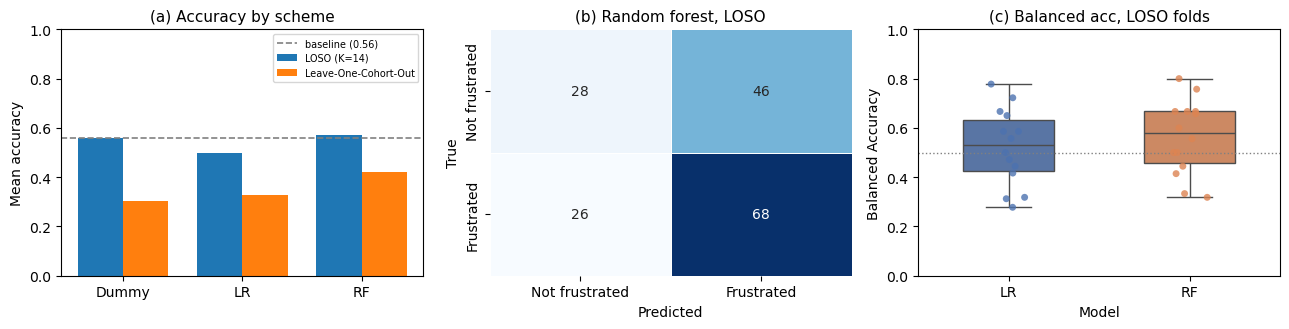

In [9]:
figc, (cA, cB, cC) = plt.subplots(1, 3, figsize=(13, 3.4))

# (A) accuracy by scheme vs baseline (primary LOSO + stress LOCO)
fig_schemes = [schemes[0], schemes[2]]
xpos = np.arange(len(MODEL_NAMES)); w = 0.38
for i, (sname, res) in enumerate(fig_schemes):
    cA.bar(xpos + (i-0.5)*w, [res[n]["fold_acc"].mean() for n in MODEL_NAMES],
           w, label=sname.split(" [")[0])
cA.axhline(MAJ, color="grey", linestyle="--", linewidth=1.2, label=f"baseline ({MAJ:.2f})")
cA.set_xticks(xpos); cA.set_xticklabels(MODEL_NAMES); cA.set_ylim(0, 1.0)
cA.set_ylabel("Mean accuracy"); cA.set_title("(a) Accuracy by scheme", fontsize=11)
cA.legend(fontsize=7)

# (B) RF confusion matrix (LOSO)
cm = confusion_matrix(loso["RF"]["y_true"], loso["RF"]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5,
            xticklabels=["Not frustrated", "Frustrated"], yticklabels=["Not frustrated", "Frustrated"], ax=cB)
cB.set_xlabel("Predicted"); cB.set_ylabel("True")
cB.set_title("(b) Random forest, LOSO", fontsize=11)

# (C) balanced accuracy spread across LOSO folds
bdf = pd.DataFrame({"Model": np.repeat(["LR", "RF"], N_SUBJECTS),
                    "Balanced Accuracy": np.r_[loso["LR"]["fold_bacc"],
                                               loso["RF"]["fold_bacc"]]})
sns.boxplot(data=bdf, x="Model", y="Balanced Accuracy", hue="Model",
            palette=["#4C72B0", "#DD8452"], ax=cC, width=0.5,
            flierprops=dict(marker=""), legend=False)
sns.stripplot(data=bdf, x="Model", y="Balanced Accuracy", hue="Model",
              palette=["#4C72B0", "#DD8452"], ax=cC, jitter=True,
              size=5, alpha=0.8, legend=False)
cC.axhline(0.5, color="grey", linestyle=":", linewidth=1); cC.set_ylim(0, 1.0)
cC.set_title("(c) Balanced acc, LOSO folds", fontsize=11)

figc.tight_layout()
figc.savefig("figures/results_report.png", dpi=150, bbox_inches="tight")
figc.savefig("figures/results_report.pdf", bbox_inches="tight")
plt.show()

## 9. Conclusions

- **HR features barely beat the majority baseline** for a *new* person: under LOSO,
  RF edges just above the baseline (0.571 vs 0.560) and LR falls below it; the
  lower-variance GroupKFold-5 nudges both up. Either way, cross-person signal is weak.
- **Models are statistically indistinguishable** — McNemar (p = 0.11) and Wilcoxon
  (p = 0.23) on the same LOSO folds; the effect size is within one fold sd.
- **No transfer across populations:** leave-one-cohort-out collapses accuracy, showing
  the two cohorts have different HR↔frustration mappings.
- The self-rated, subjective 0–10 target means each subject anchors the scale
  differently; subject-grouped CV correctly refuses to let the model memorise that
  per-person offset.

**Caveats:** one subject is single-class under the ≥2 cut (its per-fold balanced-acc is
degenerate); `Round`/`Phase` are time-ordered within subject (slide 9 pt 5), so the
within-subject temporal structure is not explicitly modelled; and CV folds reuse data,
so the comparison tests are approximate (Raschka §4.15).